In [1]:
# 机器翻译
# 给定一个源语言的句子, 自动翻译成目标语言
# 这两个句子可以有不同的长度

# Seq2Seq
# 编码器是一个RNN, 读取输入句子, 可以是双向(用在Encoder里面), 把最后的隐藏状态传给解码器
# 解码器使用另外一个RNN来输出

# 编码器-解码器细节
# 将Encoder最后一层的东西回到Decoder, 和Decoder的Input放到一起
# 编码器是没有输出的RNN
# 编码器最后步的隐状态用作隐状态的初始隐状态

# 训练
# Encoder在训练和推理的时候都一样
# 训练时Decoder使用目标句子输入, 换句话说, 即使训练的时候翻译错了, 下一个字也会将正确的作为输入

# 衡量生成序列的好坏的BLEU
# 因为之前生成的是一个词, 容易判断好坏; 这里是一个很可能长短不同的句子, 所以不容易判断好坏
# p_n是预测中所有n-gram的精度
#   - 标签序列ABCDEF和预测序列ABBCD, 有p_1 = 4/5, p_2 = 3/4, p_3 = 1/3, p_4 = 0
#   - 这里的p_1中的5是指一元组ABBCD中在ABCDEF中出现了ABCD四次
#   - 同理,  p_2中的4指二元组AB, BB, BC, CD中出现了AB, BC, CD 三次
#   - 以此类推
# BLEU定义 - BLEU越大
# exp(min(0, 1- len_label/len_pred)) (∏^k_n=1)(p_n)^(1/2^n)
# 惩罚过短的预测: len_label = 是标签长度, len_pred是预测长度;
#   - 假如预测长度比标签长度少很多的话, 1- len_label/len_pred 就是负数
#   - 那么min(0, x）就是x, exp(x)就很小
#   - 因为BLEU越大越好, 所以惩罚严重; 因为如果预测很短, 假如预测是个A, 那就是全都是1
#   - 也就是越短越容易全击中, 所以我们会惩罚过短
# 长匹配有高权重: 因为 p_n<1
#   - 当n越大, 匹配越长, 同样(1/2^n)就会越小; 对于p_n这样一个小于1的数, (1/2^n)就会越小就会导致(p_n)^(1/2^n)越大
#   - 所以n越大, 就有更高的权重, 也就是长匹配有高权重

# 总结
# Seq2Seq就是从一个句子生成到另一个句子
# Encoder和Decoder都是RNN
# 将Encoder最后时间隐状态来初始Decoder隐藏层状态来完成信息传递
# 常用BLEU来衡量生成的序列好坏

In [2]:
!pip install d2l

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.4 MB/s eta 0:00:00
  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.3/98.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.5/93.5 kB 7.8 MB/s eta 0:00:00
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)
  Attempting uninstall: requests
    Found existing installation: requests 2.32.3
    Unin

In [1]:
import collections
import math
import torch
from torch import nn
from d2l import torch as d2l

class Seq2SeqEncoder(d2l.Encoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        # vocab_size是词汇表的大小, 即模型可以处理的不同词汇的数量
        # embed_size是嵌入向量的维度大小, 在NLP处理中, 每个词汇会映射到一个固定长度的嵌入向量
        # embedding将输入的词汇索引转换为对应的嵌入向量
        super(Seq2SeqEncoder, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers, dropout=dropout)

    def forward(self, X, *args):
        X = self.embedding(X)
        X = X.permute(1, 0, 2) # 把batch_size 0放到中间, 时间1放到前面
        output, state = self.rnn(X) # 拿到输出和状态
        return output, state

In [2]:
encoder = Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16,
                        num_layers=2)
encoder.eval()
X = torch.zeros((4, 7), dtype=torch.long) # 7是每个时刻
output, state = encoder(X)
output.shape

torch.Size([7, 4, 16])

In [3]:
state.shape # 2是两层 4是batch_size

torch.Size([2, 4, 16])

In [4]:
class Seq2SeqDecoder(d2l.Decoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super(Seq2SeqDecoder, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # self.embedding是词汇索引的向量
        # embed_size是嵌入词所在的维度
        #可以被看作是将词汇表中的每个词汇映射到一个固定维度的嵌入空间中，从而得到每个词汇在这个维度空间中的索引

        # 这里不能与Encoder share因为这里的词汇不一样, 是法语
        self.rnn = nn.GRU(embed_size+num_hiddens, num_hiddens, num_layers, dropout=dropout)
        # 在解码器中, 每个时间步不仅仅需要embed_size这个维度, 还需要encode的hidden的信息
        # 所以这里的时间步的维度就是embed_size+num_hiddens
        self.dense = nn.Linear(num_hiddens, vocab_size) # 最后有个输出层

    def init_state(self, enc_outputs, *args):
        return enc_outputs[1] # enc_outputs有两个东西: output和state, 这里是拿state

    def forward(self, X, state):
        X = self.embedding(X).permute(1, 0, 2)
        # 这里将X转为词汇索引, permute后的维度顺序为(time_steps, batch_size, embed_size)
        context = state[-1].repeat(X.shape[0], 1, 1)
        # state[-1]是最后一层的隐藏状态, 形状是(num_layers, batch_size, num_hiddens)
        # 这里的X[0]是输入序列的时间步数, repeat的意思是沿着指定的维度重复张量
        # 所以这里, repeat(X.shape[0], 1, 1)意思为沿着时间步数(X.shape[0])的维度, 重复state[-1]
        # 生成形状为(X.shape[0], batch_size, num_hiddens)

        X_and_context = torch.cat((X, context), 2)
        # 这里将X和context在最后一个维度上拼接, 因为decoder要同时处理词汇的嵌入向量和上下文信息
        # 拼接后的形状是(num_steps, batch_size, embed_size+num_hiddens)
        output, state = self.rnn(X_and_context, state)

        # self.dense将output通过Linear, 转化为vocab_size的大小维度
        # 将输出调整为 (batch_size, time_steps, vocab_size)的维度, 以便预测
        output = self.dense(output).permute(1, 0, 2)
        return output, state

In [ ]:
decoder = Seq2SeqDecoder(vocab_size=10, embed_size=8, num_hiddens=16,
                         num_layers=2)
decoder.eval()
state = decoder.init_state(encoder(X))
output, state = decoder(X, state)
output.shape, state.shape

(torch.Size([4, 7, 10]), torch.Size([2, 4, 16]))

In [5]:
# 通过零值化屏蔽不相关的项
def sequence_mask(X, valid_len, value=0):
    # 这里会把valid_len之前的保留下来, 之后的都填成0
    maxlen = X.size(1)
    mask = torch.arange((maxlen), dtype=torch.float32, device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

X = torch.tensor([[1, 2, 3], [4, 5, 6]])
sequence_mask(X, torch.tensor([1, 2]))

tensor([[1, 0, 0],
        [4, 5, 0]])

In [6]:
# 拓展Softmax交叉熵来掩盖不相关的预测
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):

    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label) # 这里的weight用于: 1用于valid_len, 0用于Mask
        weights = sequence_mask(weights, valid_len)
        self.reduction = 'none' # 求loss不求mean
        unweighted_loss = super().forward(pred.permute(0, 2, 1), label) # 这里要把预测的维度放到中间
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

In [7]:
# 代码健全性检查
loss = MaskedSoftmaxCELoss()
# 生成一个样本, 3是batch_sze, 4是num_steps, 10是vocab_size
# 标号是(3,4)
# 4是说第一个样本, 4个num_steps都是valid
# 2是说第二个样本, 2个num_steps是valid
# 0是说第三个样本, 0个num_Steps是valid
loss(torch.ones(3, 4, 10), torch.ones((3, 4), dtype=torch.long),
     torch.tensor([4, 2, 0]))

tensor([2.3026, 1.1513, 0.0000])

In [26]:
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """训练序列到序列模型"""
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                     xlim=[10, num_epochs])
    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)  # 训练损失总和，词元数量
        for batch in data_iter:
            optimizer.zero_grad()

            # 核心区别
            # 原句子, 原句子的长度, 原句子的翻译, 原句子翻译的长度
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            # 加了一个begin of sentence
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                          device=device).reshape(-1, 1)
            # 这里bos是一个(batch_size, 1)的张量
            dec_input = torch.cat([bos, Y[:, :-1]], 1)
            # 这里将Y的最后一个词拿掉, 然后然后将bos和这里去掉最后一个词(时间步)的Y连接起来, 在时间步维度上
            # 因为bos在前, 所以新的Y就是: <bos> + Y[:, :-1] = [<bos>, step1, ..., step_t-1]
            Y_hat = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()
            d2l.grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1],))
    print(f'loss {metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f} '
        f'tokens/sec on {str(device)}')





loss 0.019, 7353.7 tokens/sec on cuda:0


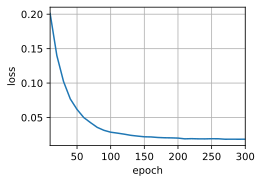

In [27]:
# 训练
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 300, d2l.try_gpu()

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)
encoder = Seq2SeqEncoder(len(src_vocab), embed_size, num_hiddens, num_layers,
                         dropout)
decoder = Seq2SeqDecoder(len(tgt_vocab), embed_size, num_hiddens, num_layers,
                         dropout)
net = d2l.EncoderDecoder(encoder, decoder)

train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)



In [28]:
# 预测
def predict_seq2seq(net, src_sentence, src_vocab, tgt_vocab, num_steps, device,
                    save_attention_weights=False):

    net.eval()
    # 将src转化成小写, 分词, 并映射为对应的索引, 最后加上eos
    src_tokens = src_vocab[src_sentence.lower().split(' ')] + [
        src_vocab['<eos>']]

    # 将这个src_tokens表示为原句子的长度, 保存
    enc_valid_len = torch.tensor([len(src_tokens)], device=device)

    # truncate_pad确保原句子的长度符合num_steps, 如果多了截掉, 少了补充pad
    src_tokens = d2l.truncate_pad(src_tokens, num_steps, src_vocab['<pad>'])

    # 将原句子转化为张量, 并将其维度拓展为(1, num_steps)用来匹配批量大小为1的格式, 序列长度为num_steps
    enc_X = torch.unsqueeze(
        torch.tensor(src_tokens, dtype=torch.long, device=device), dim=0)

    # 得到输出和隐藏状态
    enc_outputs = net.encoder(enc_X, enc_valid_len)

    # 将encoder输出的隐藏状态, 和enc_valid_len的长度作为decoder的初始层
    # 因为是预测, 所以要将真实的原句子丢入decoder
    dec_state = net.decoder.init_state(enc_outputs, enc_valid_len)

    # 将<bos>作为初始化解码器输入, 将维度拓展为(1, 1), 因为这里dim=0代表批量大小为1, unsquueze的1代表序列长度为1
    dec_X = torch.unsqueeze(
        torch.tensor([tgt_vocab['<bos>']], dtype=torch.long, device=device),
        dim=0)

    output_seq, attention_weight_seq = [], []
    for _ in range(num_steps):
        # 每次得到输出的预测Y和hidden_layers
        Y, dec_state = net.decoder(dec_X, dec_state)

        # dim=2是vocab_size的维度, 所以argmax取到vocab_size上最大的索引, 结果是(batch_size, num_steps)
        # 其中每个值是该时间步上最可能的词汇的索引
        dec_X = Y.argmax(dim=2)

        # dec_X的大小是(batch_size, num_Steps), 这里batch_size=1
        # squeeze(dim=0) 移除了batch_size, 变成了(num_steps)
        # 最后取到了num_steps上的值, 也就是最可能的词汇的所以索引
        # 这里最后以int32取出成为标量
        pred = dec_X.squeeze(dim=0).type(torch.int32).item()

        if save_attention_weights:
            attention_weight_seq.append(net.decoder.attention_weights)
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq)), attention_weight_seq

In [29]:
def bleu(pred_seq, label_seq, k):
    pred_tokens, label_tokens = pred_seq.split(' '), label_seq.split(' ')
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    score = math.exp(min(0, 1 - len_label / len_pred))

    # 这里是n-gram的计算
    for n in range(1, k+1):
        # num_matches是n-gram匹配的数量
        # label_subs是参考翻译中n-gram的计数器, 用来查看是否已经出现
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label - n + 1): # 这里是n-gram的组合数量
            # 这里将组合用''连起来
            # labels_sub统计参考翻译中每个n-gram的是否出现
            # 这里也同时生成了所有的n-gram的组合
            label_subs[''.join(label_tokens[i:i + n])] += 1
        for i in range(len_pred - n + 1): # 匹配生成翻译的n-gram

            if label_subs[''.join(pred_tokens[i:i + n])] > 0: # 生成翻译中的n-gram未被计数, 且pred_token出现了
                num_matches += 1 # 增加num_matches
                label_subs[''.join(pred_tokens[i:i + n])] -= 1# 如果翻译中存在这个n-gram, 减少其对应n-gram的计数, 防止重复计数

        # num_matches/(len_pred - n + 1)生成对应n-gram的精确度
        # math.pow(0.5, n) 计算权重
        # 最后累乘
        score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))
    return score

In [30]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, attention_weight_seq = predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device)
    print(f'{eng} => {translation}, bleu {bleu(translation, fra, k=2):.3f}')

go . => va !, bleu 1.000
i lost . => j'ai perdu ?, bleu 0.687
he's calm . => il a aller gagné ? riche riche riche ?, bleu 0.000
i'm home . => je suis chez je suis riche ., bleu 0.574
